# SKEMPI validation: does a real alanine scan agree with our recovery/entropy?

Everything in notebooks 01-04 is static geometry (contacts, distances, B-factor) or model
self-consistency (entropy, recovery of the native residue) -- never a measured binding effect. SKEMPI
2.0 is a curated database of *experimentally measured* binding-affinity changes upon mutation, and it
has a dedicated `TCR/pMHC` category (751 mutation rows, 38 complexes). One of those complexes is
**3HG1** -- the MEL5 TCR bound to ELAGIGILTV/HLA-A2 -- which also has full 4-model (ProteinMPNN,
ProteinMPNN (no MHC), ESM-IF1, LigandMPNN), T=0.1, full pMHC+TCR-context design data from this project's
earlier (pre-panel) design campaign. That overlap is the one place we can ask, with a real experiment
in hand: does a peptide position where alanine substitution measurably abolishes TCR-pMHC binding look
different, in our own recovery/entropy metrics, from a position that wasn't (or couldn't be) tested?

1. SKEMPI TCR/pMHC subset: overview, overlap with our own structures
2. 3HG1 alanine scan: which peptide positions were tested, and what happened to binding
3. Our own 3HG1 designs: per-position recovery and entropy, 4 models, full context, T=0.1
4. Cross-reference: does the alanine scan's verdict line up with our recovery/entropy?
5. Statistical comparison: SKEMPI-validated TCR-critical positions vs. everything else

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import logomaker
from pathlib import Path
from scipy.stats import mannwhitneyu

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel5_skempi_validation"
FIG_DIR.mkdir(exist_ok=True, parents=True)
AA = list("ACDEFGHIKLMNPQRSTVWY")
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
PANEL_STRUCTS = ["2P5W", "1QSF", "1QRN", "2BNR", "2GJ6", "2F53", "2F54", "3QDG", "3QEQ", "3QFJ",
                 "3GSN", "1OGA", "3UTS", "5C0A", "5C0B", "5HHO", "5EU6", "2VLR", "4MJI", "5NME"]
FOCAL_STRUCTS = ["2P5E", "3HG1"]  # this project's two primary TCR-pMHC design targets

skempi = pd.read_csv(ROOT / "inputs/skempi/skempi_tcr_pmhc.csv")
skempi["pdb_code"] = skempi["#Pdb"].str.split("_").str[0]
print(f"{len(skempi)} SKEMPI TCR/pMHC mutation rows, {skempi['pdb_code'].nunique()} distinct complexes")

751 SKEMPI TCR/pMHC mutation rows, 38 distinct complexes


## 1. SKEMPI TCR/pMHC subset: overview, overlap with our own structures

all 38 SKEMPI TCR/pMHC complexes: ['1AO7', '1BD2', '1LP9', '1MI5', '1OGA', '1QRN', '1QSE', '1QSF', '2AK4', '2BNQ', '2BNR', '2E7L', '2J8U', '2JCC', '2OI9', '2P5E', '2PYE', '2UWE', '2VLR', '3C60', '3D3V', '3H9S', '3HG1', '3PWP', '3QDG', '3QDJ', '3QFJ', '3QIB', '4FTV', '4JFD', '4JFE', '4JFF', '4L3E', '4MNQ', '4OZG', '4P23', '4P5T', '5E9D']

overlap with the 20-structure panel (notebooks 01-04): ['1OGA', '1QRN', '1QSF', '2BNR', '2VLR', '3QDG', '3QFJ']
overlap with this project's two focal design targets: ['2P5E', '3HG1']


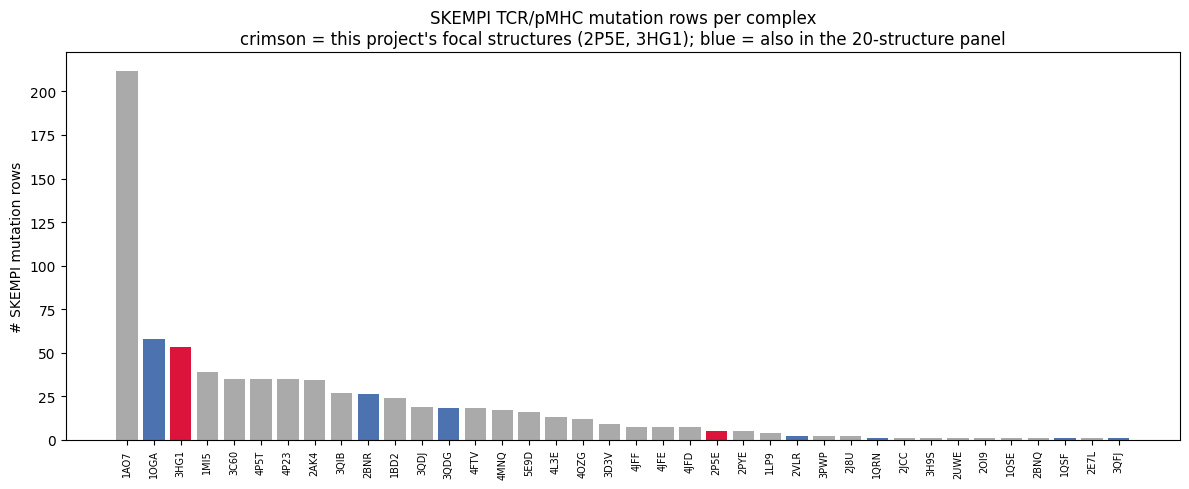

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_skempi_rows_per_complex.png


In [2]:
all_skempi_pdbs = sorted(skempi["pdb_code"].unique())
panel_overlap = sorted(set(all_skempi_pdbs) & set(PANEL_STRUCTS))
focal_overlap = sorted(set(all_skempi_pdbs) & set(FOCAL_STRUCTS))
print(f"all {len(all_skempi_pdbs)} SKEMPI TCR/pMHC complexes: {all_skempi_pdbs}")
print(f"\noverlap with the 20-structure panel (notebooks 01-04): {panel_overlap}")
print(f"overlap with this project's two focal design targets: {focal_overlap}")

rows_per_pdb = skempi.groupby("pdb_code").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["crimson" if p in FOCAL_STRUCTS else ("#4C72B0" if p in PANEL_STRUCTS else "#AAAAAA")
         for p in rows_per_pdb.index]
ax.bar(range(len(rows_per_pdb)), rows_per_pdb.values, color=colors)
ax.set_xticks(range(len(rows_per_pdb)))
ax.set_xticklabels(rows_per_pdb.index, rotation=90, fontsize=7)
ax.set_ylabel("# SKEMPI mutation rows")
ax.set_title("SKEMPI TCR/pMHC mutation rows per complex\n"
             "crimson = this project's focal structures (2P5E, 3HG1); blue = also in the 20-structure panel")
fig.tight_layout()
out = FIG_DIR / "fig_panel5_skempi_rows_per_complex.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 1b. The actual n=20 panel overlap: peptide mutations in 1QRN, 1QSF, 2BNR, 3QFJ

**3HG1 -- the subject of the rest of this notebook -- is not one of the 20 panel structures.** It's a
separate, earlier design campaign on the same TCR-pMHC family. That's a real scope gap: the richest
SKEMPI signal available happens to sit just outside the panel this whole project is otherwise about.

The n=20 panel does have real overlap with SKEMPI (7 complexes, Section 1), but only 4 of those --
1QRN, 1QSF, 2BNR, 3QFJ -- have a peptide-chain (chain C) mutation at all, and each has exactly **one**.
Nowhere near 3HG1's 5-position alanine scan, but it's the part of SKEMPI that actually maps onto data
this project has already generated in notebooks 01-04/06 (panel, full pMHC+TCR context, T=0.1).

In [3]:
panel_pep_muts = [
    {"pdb": "1QRN", "peptide": "LLFGYAVYV", "position": 6, "mutation": "A6P",
     "affinity_mut_M": "9.1E-07", "affinity_wt_M": "n.b."},
    {"pdb": "1QSF", "peptide": "LLFGYPVAV", "position": 8, "mutation": "A8Y",
     "affinity_mut_M": "9.1E-07", "affinity_wt_M": "n.b."},
    {"pdb": "2BNR", "peptide": "SLLMWITQC", "position": 9, "mutation": "C9V",
     "affinity_mut_M": "5.7E-06", "affinity_wt_M": "1.33E-05"},
    {"pdb": "3QFJ", "peptide": "LLFGFPVYV", "position": 5, "mutation": "F5Y",
     "affinity_mut_M": "9.0E-07", "affinity_wt_M": "1.2E-06"},
]

def peptide_from_ligandmpnn_line(line):
    return line.strip().split(":")[2]

def load_panel_designs(pdb, length):
    rows = []
    for weights, fname in [("vanilla", f"vanilla_{pdb}.fa"), ("noMHC", f"nomhc_{pdb}.fa")]:
        path = ROOT / f"outputs/panel/{pdb}/full/mpnn/seqs/{fname}"
        with open(path) as f:
            lines = f.read().splitlines()
        for i in range(2, len(lines) - 1, 2):
            if lines[i].startswith(">"):
                seq = lines[i + 1].strip()
                if len(seq) == length:
                    rows.append({"peptide": seq, "model": weights})
    path = ROOT / f"outputs/panel/{pdb}/full/esmif/seqs/{pdb}.fa"
    with open(path) as f:
        lines = f.read().splitlines()
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = lines[i + 1].strip()
            if len(seq) == length:
                rows.append({"peptide": seq, "model": "ESM-IF1"})
    path = ROOT / f"outputs/panel/{pdb}/full/ligandmpnn/seqs/{pdb}.fa"
    with open(path) as f:
        lines = f.read().splitlines()
    for i in range(2, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = peptide_from_ligandmpnn_line(lines[i + 1])
            if len(seq) == length:
                rows.append({"peptide": seq, "model": "LigandMPNN"})
    return pd.DataFrame(rows)

def shannon_entropy_local(counts):
    counts = np.array(counts, dtype=float)
    counts = counts[counts > 0]
    if counts.sum() == 0:
        return np.nan
    p = counts / counts.sum()
    return -(p * np.log2(p)).sum()

for rec in panel_pep_muts:
    pdb, length, pos0 = rec["pdb"], len(rec["peptide"]), rec["position"] - 1
    panel_designs = load_panel_designs(pdb, length)
    all_peps = panel_designs["peptide"].tolist()
    col = [p[pos0] for p in all_peps]
    rec["our_recovery"] = float(np.mean([aa == rec["peptide"][pos0] for aa in col]))
    rec["our_entropy"] = shannon_entropy_local(pd.Series(col).value_counts().values)
    rec["is_anchor"] = rec["position"] in (2, length)
    rec["n_designs"] = len(all_peps)

panel_pep_df = pd.DataFrame(panel_pep_muts)
panel_pep_df

,pdb,peptide,position,mutation,affinity_mut_M,affinity_wt_M,our_recovery,our_entropy,is_anchor,n_designs
0,1QRN,LLFGYAVYV,6,A6P,9.1E-07,n.b.,0.00000,0.814257,False,40016
1,1QSF,LLFGYPVAV,8,A8Y,9.1E-07,n.b.,0.01217,1.722759,False,40016
2,2BNR,SLLMWITQC,9,C9V,5.7E-06,1.33E-05,0.00000,1.070650,True,40016
3,3QFJ,LLFGFPVYV,5,F5Y,9.0E-07,1.2E-06,0.95082,0.294967,False,40016


2BNR's tested position (9, the C-terminal P$\Omega$ anchor of this 9-mer) is the one clean
quantitative pair here: the native Cys is measured at 1.33e-05 M, the C9V mutant at 5.7e-06 M -- V binds
*tighter* than the crystallized native residue. If the native anchor residue isn't uniquely optimal for
affinity, that's a plausible piece of *why* this project keeps finding low recovery at $P\Omega$ across
every structure in the panel (notebook 03) -- not necessarily a model failure, but the position
tolerating (or even preferring) alternatives to the one residue that happened to get crystallized.
$n=4$ points, one per structure, is far too little to lean on this hard -- it's a lead worth keeping in
mind alongside the richer 3HG1 case study below, not a replacement for it.

## 2. 3HG1 alanine scan: which peptide positions were tested, and what happened to binding

3HG1's native peptide is **ELAGIGILTV** (the MART-1/MelanA decapeptide, HLA-A2-restricted). Position 3
is already alanine in the wild type, so it can't be alanine-scanned in the usual sense. SKEMPI's
`Mutation(s)_PDB` codes chain C as the peptide -- filtering to single, peptide-only mutations isolates
a clean per-position readout (the combined peptide+TCR-CDR mutations below are also n.b., but that's
uninformative once the peptide side alone already abolishes binding).

In [4]:
native_3hg1 = "ELAGIGILTV"
length_3hg1 = len(native_3hg1)

skempi_3hg1 = skempi[skempi.pdb_code == "3HG1"].copy()
skempi_3hg1["muts_list"] = skempi_3hg1["Mutation(s)_PDB"].str.split(",")
skempi_3hg1["chains"] = skempi_3hg1["muts_list"].apply(lambda ms: set(m[1] for m in ms))
skempi_3hg1["peptide_only"] = skempi_3hg1["chains"] == {"C"}

pep_only = skempi_3hg1[skempi_3hg1["peptide_only"]][
    ["Mutation(s)_PDB", "Affinity_mut (M)", "Affinity_wt (M)"]]
print(f"{len(skempi_3hg1)} total 3HG1 rows; {skempi_3hg1['peptide_only'].sum()} are peptide-only mutations")
pep_only

53 total 3HG1 rows; 5 are peptide-only mutations


,Mutation(s)_PDB,Affinity_mut (M),Affinity_wt (M)
477,GC4A,n.b,2.6E-05
478,GC6A,n.b,2.6E-05
479,IC7A,n.b,2.6E-05
480,LC8A,n.b,2.6E-05
481,TC9A,n.b,2.6E-05


In [5]:
tested_positions = {}  # 1-indexed peptide position -> outcome
for _, row in pep_only.iterrows():
    mut = row["Mutation(s)_PDB"]  # e.g. "GC4A" = native G, chain C, position 4, mutated to A
    pos = int(mut[2:-1])
    tested_positions[pos] = row["Affinity_mut (M)"]

CATEGORY = {}
for pos in range(1, length_3hg1 + 1):
    if pos in tested_positions:
        CATEGORY[pos] = "Ala abolishes binding (SKEMPI-tested)"
    elif native_3hg1[pos - 1] == "A":
        CATEGORY[pos] = "already Ala in WT (untestable)"
    elif pos in (2, length_3hg1):
        CATEGORY[pos] = "known MHC anchor (untested)"
    else:
        CATEGORY[pos] = "not tested"

for pos in range(1, length_3hg1 + 1):
    print(f"P{pos} ({native_3hg1[pos - 1]}): {CATEGORY[pos]}"
          + (f" -- affinity_mut={tested_positions[pos]}" if pos in tested_positions else ""))

P1 (E): not tested
P2 (L): known MHC anchor (untested)
P3 (A): already Ala in WT (untestable)
P4 (G): Ala abolishes binding (SKEMPI-tested) -- affinity_mut=n.b
P5 (I): not tested
P6 (G): Ala abolishes binding (SKEMPI-tested) -- affinity_mut=n.b
P7 (I): Ala abolishes binding (SKEMPI-tested) -- affinity_mut=n.b
P8 (L): Ala abolishes binding (SKEMPI-tested) -- affinity_mut=n.b
P9 (T): Ala abolishes binding (SKEMPI-tested) -- affinity_mut=n.b
P10 (V): known MHC anchor (untested)


## 3. Our own 3HG1 designs: per-position recovery and entropy, 4 models, full context, T=0.1

Same pipeline convention as the panel notebooks -- raw design draws (not deduplicated), pMHC+TCR
context, T=0.1. 3HG1 isn't part of the 20-structure panel campaign, so its designs come from this
project's earlier full-matrix design campaign instead (`outputs/mpnn_3hg1_100k`,
`outputs/esmif_3hg1_pilot`, `outputs/ligandmpnn_3hg1_pilot`), same models, same temperature, same
full pMHC+TCR context.

In [6]:
def peptide_from_ligandmpnn_line(line):
    return line.strip().split(":")[2]

def load_3hg1_designs():
    rows = []
    vanilla_path = ROOT / "outputs/mpnn_3hg1_100k/archive_T01_partial/vanilla_3HG1_T01_partial_26993.fa"
    nomhc_path = ROOT / "outputs/mpnn_3hg1_100k/archive_T01_partial/nomhc_3HG1_T01_partial_26528.fa"
    for weights, path in [("vanilla", vanilla_path), ("noMHC", nomhc_path)]:
        with open(path) as f:
            lines = f.read().splitlines()
        for i in range(2, len(lines) - 1, 2):  # skip the first (reference) record
            if lines[i].startswith(">"):
                seq = lines[i + 1].strip()
                if len(seq) == length_3hg1:
                    rows.append({"peptide": seq, "model": weights})

    esmif_path = ROOT / "outputs/esmif_3hg1_pilot/seqs/3HG1.fa"
    with open(esmif_path) as f:
        lines = f.read().splitlines()
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = lines[i + 1].strip()
            if len(seq) == length_3hg1:
                rows.append({"peptide": seq, "model": "ESM-IF1"})

    lig_path = ROOT / "outputs/ligandmpnn_3hg1_pilot/seqs/3HG1.fa"
    with open(lig_path) as f:
        lines = f.read().splitlines()
    for i in range(2, len(lines) - 1, 2):  # skip the first (reference) record
        if lines[i].startswith(">"):
            seq = peptide_from_ligandmpnn_line(lines[i + 1])
            if len(seq) == length_3hg1:
                rows.append({"peptide": seq, "model": "LigandMPNN"})
    return pd.DataFrame(rows)

designs_3hg1 = load_3hg1_designs()
print(designs_3hg1.groupby("model").size())

model
ESM-IF1       10000
LigandMPNN    10048
noMHC         26527
vanilla       26992
dtype: int64


In [7]:
def shannon_entropy(counts):
    counts = np.array(counts, dtype=float)
    counts = counts[counts > 0]
    if counts.sum() == 0:
        return np.nan
    p = counts / counts.sum()
    return -(p * np.log2(p)).sum()

per_position_records = []
for model in MODELS:
    peps = designs_3hg1.loc[designs_3hg1.model == model, "peptide"].tolist()
    for pos in range(length_3hg1):
        col = [p[pos] for p in peps]
        recovery = float(np.mean([aa == native_3hg1[pos] for aa in col]))
        counts = pd.Series(col).value_counts()
        entropy = shannon_entropy(counts.values)
        per_position_records.append({"position": pos + 1, "model": model, "recovery": recovery,
                                     "entropy": entropy})

# pooled: all 4 models' raw designs combined
all_peps = designs_3hg1["peptide"].tolist()
pooled_records = []
for pos in range(length_3hg1):
    col = [p[pos] for p in all_peps]
    recovery = float(np.mean([aa == native_3hg1[pos] for aa in col]))
    counts = pd.Series(col).value_counts()
    entropy = shannon_entropy(counts.values)
    pooled_records.append({"position": pos + 1, "recovery": recovery, "entropy": entropy})

per_position_df = pd.DataFrame(per_position_records)
pooled_df = pd.DataFrame(pooled_records)
pooled_df["category"] = pooled_df["position"].map(CATEGORY)
pooled_df["native_aa"] = pooled_df["position"].apply(lambda p: native_3hg1[p - 1])
pooled_df

,position,recovery,entropy,category,native_aa
0,1,0.000000,0.007701,not tested,E
1,2,0.735955,1.194955,known MHC anchor (untested),L
2,3,0.028409,0.674685,already Ala in WT (untestable),A
3,4,0.847268,0.692989,Ala abolishes binding (SKEMPI-tested),G
4,5,0.725271,0.848383,not tested,I
5,6,1.000000,-0.000000,Ala abolishes binding (SKEMPI-tested),G
6,7,0.946674,0.337685,Ala abolishes binding (SKEMPI-tested),I
7,8,0.013185,1.794548,Ala abolishes binding (SKEMPI-tested),L
8,9,0.139003,0.657887,Ala abolishes binding (SKEMPI-tested),T
9,10,0.000000,0.583493,known MHC anchor (untested),V


## 4. Cross-reference: does the alanine scan's verdict line up with our recovery/entropy?

Per-model (4 columns) and all-models-pooled (black), recovery and entropy, one plot per position --
colored/marked by SKEMPI category. If our metrics tracked real TCR-binding importance, the SKEMPI-tested
positions (which we *know* are functionally critical -- alanine there measurably kills binding) should
look distinct from the untested ones.

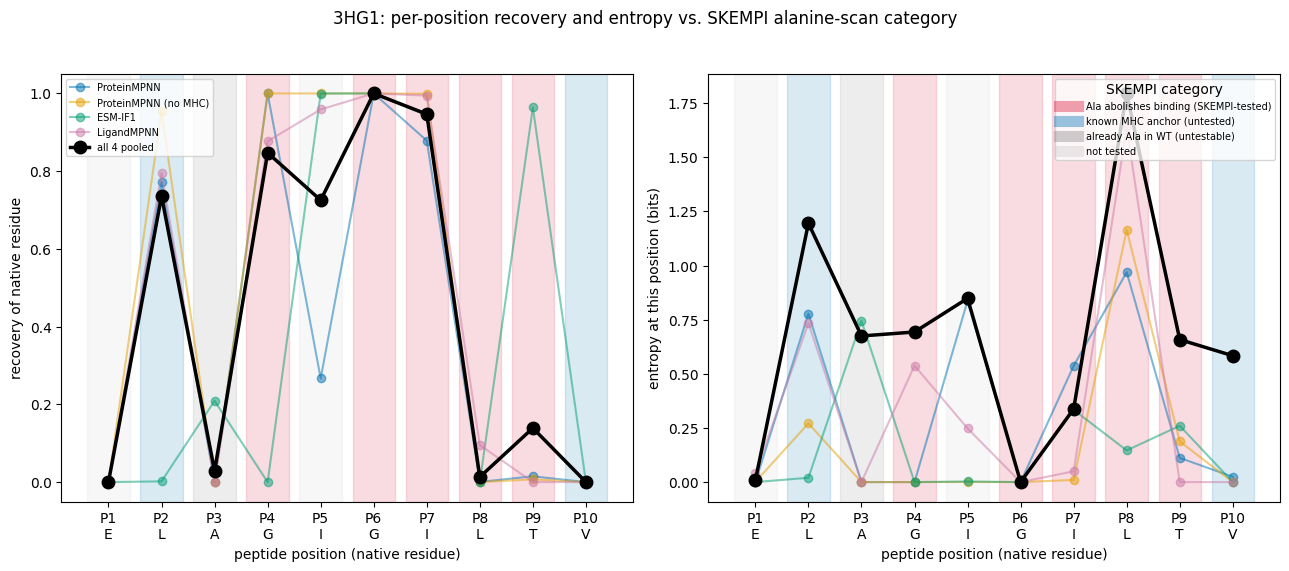

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_3hg1_recovery_entropy_vs_skempi.png


In [8]:
CATEGORY_COLOR = {
    "Ala abolishes binding (SKEMPI-tested)": "crimson",
    "known MHC anchor (untested)": "#0072B2",
    "already Ala in WT (untestable)": "#888888",
    "not tested": "#CCCCCC",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, ycol, ylabel in [(axes[0], "recovery", "recovery of native residue"),
                         (axes[1], "entropy", "entropy at this position (bits)")]:
    for model in MODELS:
        sub = per_position_df[per_position_df.model == model]
        ax.plot(sub["position"], sub[ycol], "o-", color=MODEL_COLOR[model], alpha=0.5, markersize=6,
               label=MODEL_LABEL[model])
    ax.plot(pooled_df["position"], pooled_df[ycol], "o-", color="black", linewidth=2.5, markersize=9,
           label="all 4 pooled", zorder=5)
    for _, row in pooled_df.iterrows():
        ax.axvspan(row["position"] - 0.4, row["position"] + 0.4,
                  color=CATEGORY_COLOR[row["category"]], alpha=0.15, zorder=0)
    ax.set_xticks(pooled_df["position"])
    ax.set_xticklabels([f"P{p}\n{native_3hg1[p - 1]}" for p in pooled_df["position"]])
    ax.set_xlabel("peptide position (native residue)")
    ax.set_ylabel(ylabel)
handles = [plt.Line2D([0], [0], color=c, lw=8, alpha=0.4, label=lbl) for lbl, c in CATEGORY_COLOR.items()]
axes[0].legend(fontsize=7, loc="upper left")
axes[1].legend(handles=handles, fontsize=7, loc="upper right", title="SKEMPI category")
fig.suptitle("3HG1: per-position recovery and entropy vs. SKEMPI alanine-scan category", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel5_3hg1_recovery_entropy_vs_skempi.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Design logo, all 4 models pooled, x-axis annotated with SKEMPI category

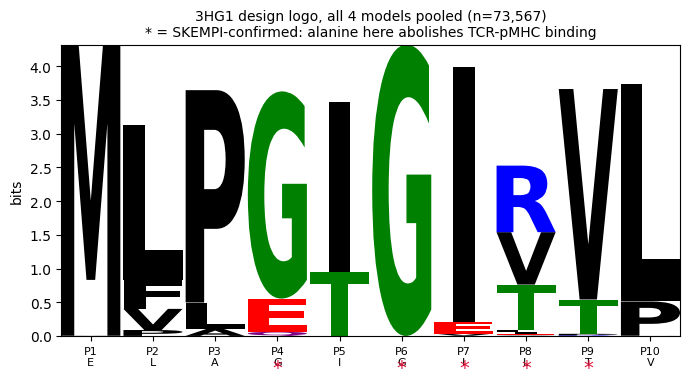

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_3hg1_design_logo.png


In [9]:
mat = pd.DataFrame(0.0, index=range(1, length_3hg1 + 1), columns=AA)
for pep in all_peps:
    for pos, aa in enumerate(pep, start=1):
        if aa in AA:
            mat.loc[pos, aa] += 1.0
info_mat = logomaker.transform_matrix(mat, from_type="counts", to_type="information", pseudocount=0.1)

fig, ax = plt.subplots(figsize=(7, 4))
logomaker.Logo(info_mat, ax=ax, color_scheme="chemistry")
ax.set_ylim(0, np.log2(len(AA)))
ax.set_xticks(range(1, length_3hg1 + 1))
ax.set_xticklabels([f"P{p}\n{native_3hg1[p - 1]}" for p in range(1, length_3hg1 + 1)], fontsize=8)
for p in range(1, length_3hg1 + 1):
    ax.text(p, -0.55, "*" if CATEGORY[p].startswith("Ala abolishes") else "", ha="center", fontsize=14,
           color="crimson", clip_on=False)
ax.set_ylabel("bits")
ax.set_title(f"3HG1 design logo, all 4 models pooled (n={len(all_peps):,})\n"
            "* = SKEMPI-confirmed: alanine here abolishes TCR-pMHC binding", fontsize=10)
fig.tight_layout()
out = FIG_DIR / "fig_panel5_3hg1_design_logo.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 5. Statistical comparison: SKEMPI-validated TCR-critical positions vs. everything else

$n=5$ tested positions vs. $n=5$ untested, all-models-pooled recovery and entropy -- Mann-Whitney U
(unpaired, since these are different positions, not matched samples). With $n=5$ per group this is
underpowered and exploratory, not a confirmatory test; treat the p-value as a rough signal, not proof.

In [10]:
tested_pos = [p for p, c in CATEGORY.items() if c.startswith("Ala abolishes")]
other_pos = [p for p, c in CATEGORY.items() if not c.startswith("Ala abolishes")]
print(f"SKEMPI-critical positions: {tested_pos} ({[native_3hg1[p - 1] for p in tested_pos]})")
print(f"everything else: {other_pos} ({[native_3hg1[p - 1] for p in other_pos]})")

for ycol in ["recovery", "entropy"]:
    tested_vals = pooled_df.loc[pooled_df.position.isin(tested_pos), ycol].values
    other_vals = pooled_df.loc[pooled_df.position.isin(other_pos), ycol].values
    stat, p = mannwhitneyu(tested_vals, other_vals, alternative="two-sided")
    print(f"\n{ycol}: SKEMPI-critical mean={tested_vals.mean():.3f}, everything-else mean="
          f"{other_vals.mean():.3f}, Mann-Whitney p={p:.3f} (n=5 vs n=5)")

print("\n--- and the two known MHC anchors specifically (P2, P10) vs. the 5 SKEMPI-critical positions ---")
anchor_pos = [p for p, c in CATEGORY.items() if c == "known MHC anchor (untested)"]
for ycol in ["recovery", "entropy"]:
    anchor_vals = pooled_df.loc[pooled_df.position.isin(anchor_pos), ycol].values
    tested_vals = pooled_df.loc[pooled_df.position.isin(tested_pos), ycol].values
    print(f"{ycol}: anchors {dict(zip(anchor_pos, anchor_vals.round(3)))}, "
          f"SKEMPI-critical mean={tested_vals.mean():.3f}")

SKEMPI-critical positions: [4, 6, 7, 8, 9] (['G', 'G', 'I', 'L', 'T'])
everything else: [1, 2, 3, 5, 10] (['E', 'L', 'A', 'I', 'V'])

recovery: SKEMPI-critical mean=0.589, everything-else mean=0.298, Mann-Whitney p=0.142 (n=5 vs n=5)

entropy: SKEMPI-critical mean=0.697, everything-else mean=0.662, Mann-Whitney p=0.841 (n=5 vs n=5)

--- and the two known MHC anchors specifically (P2, P10) vs. the 5 SKEMPI-critical positions ---
recovery: anchors {2: np.float64(0.736), 10: np.float64(0.0)}, SKEMPI-critical mean=0.589
entropy: anchors {2: np.float64(1.195), 10: np.float64(0.583)}, SKEMPI-critical mean=0.697


## 6. Do the models actually pick up the TCR-recognition motif, and does removing the TCR erode it?

Two separate questions, both usable now that SKEMPI has told us which 5 positions (P4, P6, P7, P8, P9)
are confirmed TCR-critical, independent of the pMHC anchoring story (P2, P$\Omega$):

1. **Do the models understand this motif?** Recovery (matching the native residue) is one signal, but a
   stronger one is *cross-model agreement*: if four independently-trained, architecturally different
   models (ProteinMPNN, ProteinMPNN (no MHC), ESM-IF1, LigandMPNN) all converge on the same residue at a
   position with no coordination between them, that position is carrying a real, learnable constraint --
   not a quirk of one model's training. Measured here as each model's own single most-common (mode)
   residue at a position, then how many of the models' modes agree with each other.
2. **Does removing the TCR erode it?** If the TCR-critical positions are actually learned as
   TCR-recognition constraints (not just generic peptide stability), removing the TCR from the design
   context should hurt recovery/agreement at P4/6/7/8/9 specifically, while leaving the pMHC-anchor
   positions (P2, P$\Omega$) comparatively unaffected -- that contrast is the actual test, not just "does
   mhconly recovery drop somewhere."

Only 3 of the 4 models have a true pMHC-only (no TCR, MHC still present) run for 3HG1 in this project's
earlier campaign -- ProteinMPNN, ProteinMPNN (no MHC), and LigandMPNN. ESM-IF1 only has a "nocontext"
run (MHC *and* TCR both removed), which would confound the comparison, so ESM-IF1 is excluded from this
section specifically (it's still in every other section of this notebook).

In [11]:
MHCONLY_MODELS = ["vanilla", "noMHC", "LigandMPNN"]

def load_3hg1_mhconly_designs():
    rows = []
    vanilla_path = ROOT / "outputs/context_ablation_3hg1/mpnn_mhconly/seqs/vanilla_3HG1_mhconly.fa"
    nomhc_path = ROOT / "outputs/context_ablation_3hg1/mpnn_mhconly/seqs/nomhc_3HG1_mhconly.fa"
    for weights, path in [("vanilla", vanilla_path), ("noMHC", nomhc_path)]:
        with open(path) as f:
            lines = f.read().splitlines()
        for i in range(2, len(lines) - 1, 2):
            if lines[i].startswith(">"):
                seq = lines[i + 1].strip()
                if len(seq) == length_3hg1:
                    rows.append({"peptide": seq, "model": weights})

    lig_path = ROOT / "outputs/context_ablation_3hg1/ligandmpnn_mhconly/seqs/3HG1.fa"
    with open(lig_path) as f:
        lines = f.read().splitlines()
    for i in range(2, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = peptide_from_ligandmpnn_line(lines[i + 1])
            if len(seq) == length_3hg1:
                rows.append({"peptide": seq, "model": "LigandMPNN"})
    return pd.DataFrame(rows)

designs_3hg1_mhconly = load_3hg1_mhconly_designs()
print(designs_3hg1_mhconly.groupby("model").size())

def model_mode_agreement(peps_by_model, length):
    records = []
    for pos in range(length):
        modes = {model: pd.Series([p[pos] for p in peps]).value_counts().idxmax()
                for model, peps in peps_by_model.items()}
        vote_counts = pd.Series(list(modes.values())).value_counts()
        records.append({"position": pos + 1, "consensus_aa": vote_counts.index[0],
                        "n_agree": int(vote_counts.iloc[0]), "n_models": len(peps_by_model),
                        "modes": modes})
    return pd.DataFrame(records)

def pooled_recovery_by_position(peps_by_model, native, length):
    all_peps = [p for peps in peps_by_model.values() for p in peps]
    return [float(np.mean([p[pos] == native[pos] for p in all_peps])) for pos in range(length)]

peps_full_3model = {m: designs_3hg1.loc[designs_3hg1.model == m, "peptide"].tolist() for m in MHCONLY_MODELS}
peps_mhconly_3model = {m: designs_3hg1_mhconly.loc[designs_3hg1_mhconly.model == m, "peptide"].tolist()
                       for m in MHCONLY_MODELS}

agreement_full = model_mode_agreement(peps_full_3model, length_3hg1)
agreement_mhconly = model_mode_agreement(peps_mhconly_3model, length_3hg1)
recovery_full_3model = pooled_recovery_by_position(peps_full_3model, native_3hg1, length_3hg1)
recovery_mhconly_3model = pooled_recovery_by_position(peps_mhconly_3model, native_3hg1, length_3hg1)

shift_df = pd.DataFrame({
    "position": range(1, length_3hg1 + 1),
    "native_aa": list(native_3hg1),
    "category": [CATEGORY[p] for p in range(1, length_3hg1 + 1)],
    "recovery_full": recovery_full_3model,
    "recovery_mhconly": recovery_mhconly_3model,
    "n_agree_full": agreement_full["n_agree"],
    "n_agree_mhconly": agreement_mhconly["n_agree"],
})
shift_df["recovery_delta"] = shift_df["recovery_full"] - shift_df["recovery_mhconly"]
shift_df["agreement_delta"] = shift_df["n_agree_full"] - shift_df["n_agree_mhconly"]
shift_df

model
LigandMPNN    5024
noMHC         5000
vanilla       5000
dtype: int64


,position,native_aa,category,recovery_full,recovery_mhconly,n_agree_full,n_agree_mhconly,recovery_delta,agreement_delta
0,1,E,not tested,0.000000,0.000000,3,3,0.000000,0
1,2,L,known MHC anchor (untested),0.851432,0.928980,3,3,-0.077548,0
2,3,A,already Ala in WT (untestable),0.000000,0.000067,3,3,-0.000067,0
3,4,G,Ala abolishes binding (SKEMPI-tested),0.980556,0.000000,3,2,0.980556,1
4,5,I,not tested,0.682083,0.000000,2,2,0.682083,0
5,6,G,Ala abolishes binding (SKEMPI-tested),1.000000,1.000000,3,3,0.000000,0
6,7,I,Ala abolishes binding (SKEMPI-tested),0.947205,0.999201,3,3,-0.051996,0
7,8,L,Ala abolishes binding (SKEMPI-tested),0.015259,0.000000,2,1,0.015259,1
8,9,T,Ala abolishes binding (SKEMPI-tested),0.009234,0.000266,3,3,0.008968,0
9,10,V,known MHC anchor (untested),0.000000,0.000000,3,3,0.000000,0


### Recovery and cross-model agreement, full vs. pMHC-only, per position

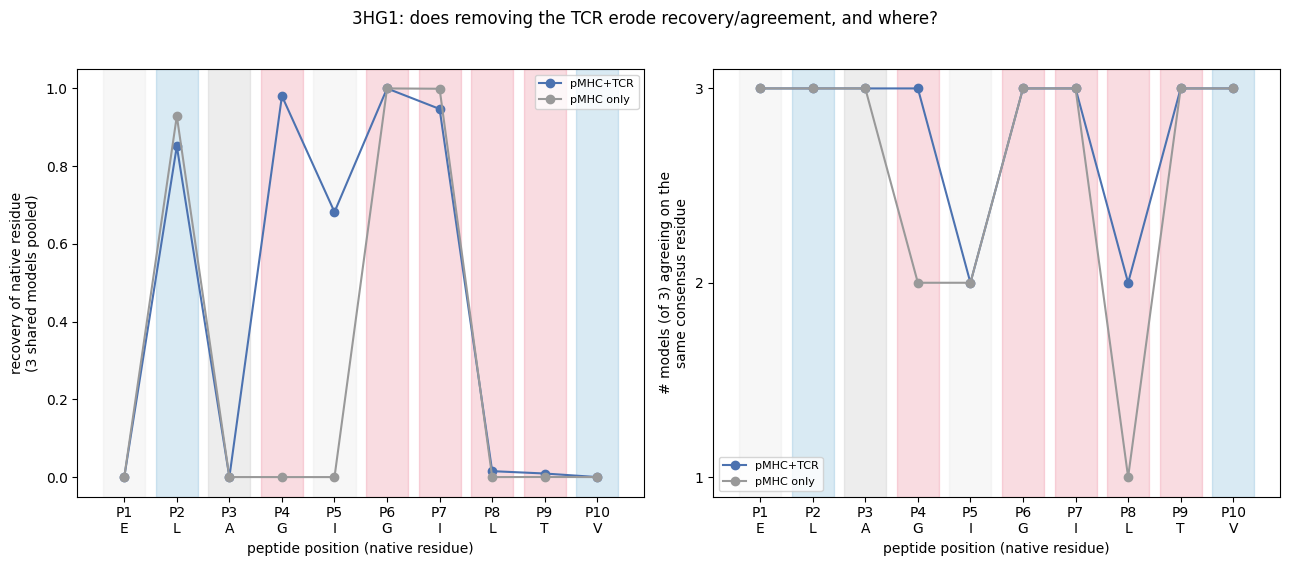

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_3hg1_full_vs_mhconly_shift.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
x = shift_df["position"]
axes[0].plot(x, shift_df["recovery_full"], "o-", color="#4C72B0", label="pMHC+TCR")
axes[0].plot(x, shift_df["recovery_mhconly"], "o-", color="#999999", label="pMHC only")
axes[0].set_ylabel("recovery of native residue\n(3 shared models pooled)")
axes[0].legend(fontsize=8)

axes[1].plot(x, shift_df["n_agree_full"], "o-", color="#4C72B0", label="pMHC+TCR")
axes[1].plot(x, shift_df["n_agree_mhconly"], "o-", color="#999999", label="pMHC only")
axes[1].set_ylabel("# models (of 3) agreeing on the\nsame consensus residue")
axes[1].set_yticks([1, 2, 3])
axes[1].legend(fontsize=8)

for ax in axes:
    for _, row in shift_df.iterrows():
        ax.axvspan(row["position"] - 0.4, row["position"] + 0.4,
                  color=CATEGORY_COLOR[row["category"]], alpha=0.15, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([f"P{p}\n{native_3hg1[p - 1]}" for p in x])
    ax.set_xlabel("peptide position (native residue)")
fig.suptitle("3HG1: does removing the TCR erode recovery/agreement, and where?", y=1.02)
fig.tight_layout()
out = FIG_DIR / "fig_panel5_3hg1_full_vs_mhconly_shift.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Is the shift concentrated at the SKEMPI-confirmed TCR-critical positions?

If the TCR-critical positions are genuinely learned as TCR-recognition constraints (not generic peptide
stability), the full-to-mhconly *drop* in recovery/agreement should be larger there than at the
pMHC-anchor positions or the untested ones. $n=5$ vs $n=5$ (or $n=2$ for the anchor-only comparison) --
small, exploratory, not confirmatory.

In [13]:
tested_pos = [p for p, c in CATEGORY.items() if c.startswith("Ala abolishes")]
anchor_pos = [p for p, c in CATEGORY.items() if c == "known MHC anchor (untested)"]
other_pos = [p for p, c in CATEGORY.items() if not c.startswith("Ala abolishes")]

for col in ["recovery_delta", "agreement_delta"]:
    tested_vals = shift_df.loc[shift_df.position.isin(tested_pos), col].values
    other_vals = shift_df.loc[shift_df.position.isin(other_pos), col].values
    anchor_vals = shift_df.loc[shift_df.position.isin(anchor_pos), col].values
    stat, p = mannwhitneyu(tested_vals, other_vals, alternative="two-sided")
    print(f"{col}: SKEMPI-critical mean={tested_vals.mean():+.3f} (positions {tested_pos}), "
         f"everything-else mean={other_vals.mean():+.3f}, Mann-Whitney p={p:.3f}")
    print(f"  -- for reference, the 2 known MHC anchors alone: {dict(zip(anchor_pos, anchor_vals.round(3)))}")
print("\n(positive delta = pMHC+TCR context recovers/agrees more than pMHC-only; "
     "negative = pMHC-only does better)")

recovery_delta: SKEMPI-critical mean=+0.191 (positions [4, 6, 7, 8, 9]), everything-else mean=+0.121, Mann-Whitney p=0.398
  -- for reference, the 2 known MHC anchors alone: {2: np.float64(-0.078), 10: np.float64(0.0)}
agreement_delta: SKEMPI-critical mean=+0.400 (positions [4, 6, 7, 8, 9]), everything-else mean=+0.000, Mann-Whitney p=0.177
  -- for reference, the 2 known MHC anchors alone: {2: np.int64(0), 10: np.int64(0)}

(positive delta = pMHC+TCR context recovers/agrees more than pMHC-only; negative = pMHC-only does better)


## 7. IEDB: real TCR-binding measurements across the whole panel

**A caveat first, because it matters for how to read everything below:** almost none of these
measurements can cleanly separate "this mutation broke peptide-MHC loading" from "this mutation broke
TCR recognition specifically." A `cytotoxicity`, `activation`, `IL-2 release`, or `proliferation` result
is a net functional readout -- it goes negative if the peptide stops binding the MHC well enough to be
presented, *or* if it's presented fine but the TCR no longer recognizes it, and IEDB's abstracted
`qualitative_measure` field doesn't distinguish the two. `qualitative binding|multimer/tetramer` is a bit
cleaner (a multimer has to be a stable, correctly folded pMHC to even be made), but is still a yes/no
stain, not a binding measurement. The one assay type here that's actually run *after* the pMHC complex
is already confirmed stably folded is `dissociation constant KD|surface plasmon resonance (SPR)` --
refolding has to succeed before an SPR experiment is even possible, so a KD change measured this way is
the closest thing in this dataset to an isolated TCR-engagement effect. Where it matters below, the
assay type is called out explicitly rather than treating every "Negative" the same.

Using the 13 TCR clones from Section 1, matched by CDR3 back to IEDB's `tcell_search`, then re-diffed
against each individual panel structure's own native peptide (accounting for a shared background
mutation where one exists, e.g. 5EU6's variants are all also P9A) -- 44 (structure, position) pairs
across the panel have at least one real single-position IEDB variant tested, and 21 of those show a
"Negative" or "Positive-Low" result somewhere: real evidence that position matters for binding.

In [14]:
master_full = pd.read_csv(ROOT / "outputs/analysis/panel_dataset_master_table.csv").set_index("pdb")

GROUP_MAP = {
    "1OGA": "1OGA", "2VLR": "2VLR", "5HHO": "5HHO", "3QEQ": "3QEQ",
    "3UTS": "3UTS,5C0A,5C0B", "5C0A": "3UTS,5C0A,5C0B", "5C0B": "3UTS,5C0A,5C0B",
    "3GSN": "3GSN", "4MJI": "4MJI", "5EU6": "5EU6", "3QDG": "3QDG", "2P5W": "2P5W",
    "2BNR": "2BNR,2F53,2F54", "2F53": "2BNR,2F53,2F54", "2F54": "2BNR,2F53,2F54",
    "5NME": "5NME", "1QSF": "1QSF,1QRN,2GJ6,3QFJ", "1QRN": "1QSF,1QRN,2GJ6,3QFJ",
    "2GJ6": "1QSF,1QRN,2GJ6,3QFJ", "3QFJ": "1QSF,1QRN,2GJ6,3QFJ",
}
with open(ROOT / "inputs/iedb/tcr_matched_raw.json") as f:
    iedb_raw = json.load(f)

per_pdb_variants = {}
for pdb, group in GROUP_MAP.items():
    native = master_full.loc[pdb, "peptide"]
    length = len(native)
    variants = []
    for r in iedb_raw[group]:
        pep = r["linear_sequence"]
        if len(pep) != length:
            continue
        diffs = tuple(i + 1 for i, (a, b) in enumerate(zip(native, pep)) if a != b)
        if not diffs:
            continue
        variants.append({"diffs": diffs, "qual": r["qualitative_measure"], "assay": r["assay_names"],
                         "pubmed_id": r["pubmed_id"]})
    per_pdb_variants[pdb] = variants

# Section 1b (SKEMPI) already presented these exact measurements, from these exact papers -- reusing
# them here via IEDB, unlabeled, would silently double-count the same experiment as if it were a second,
# independent source. Flag (not silently drop) any IEDB row citing the same PMID.
SKEMPI_PANEL_PMIDS = {"1QRN": "10435578", "1QSF": "10435578", "2BNR": "15837811", "3QFJ": "22019736"}

position_records = []
for pdb, variants in per_pdb_variants.items():
    native = master_full.loc[pdb, "peptide"]
    multi = [v for v in variants if len(v["diffs"]) > 1]
    background_pos = None
    if multi:
        common = set(multi[0]["diffs"])
        for v in multi[1:]:
            common &= set(v["diffs"])
        if len(common) == 1:
            background_pos = next(iter(common))
    for v in variants:
        diffs = v["diffs"]
        if len(diffs) == 1:
            tested = diffs[0]
        elif background_pos is not None and background_pos in diffs and len(diffs) == 2:
            tested = [d for d in diffs if d != background_pos][0]
        else:
            continue
        same_as_skempi = v["pubmed_id"] == SKEMPI_PANEL_PMIDS.get(pdb)
        position_records.append({"pdb": pdb, "position": tested, "native_aa": native[tested - 1],
                                 "qualitative_measure": v["qual"], "assay": v["assay"],
                                 "pubmed_id": v["pubmed_id"], "same_source_as_skempi_1b": same_as_skempi})

variant_df = pd.DataFrame(position_records).drop_duplicates()
SEVERITY = {"Negative": 0, "Positive-Low": 1, "Positive-Intermediate": 2, "Positive": 3, "Positive-High": 4}
variant_df["severity"] = variant_df["qualitative_measure"].map(SEVERITY)

position_summary = variant_df.groupby(["pdb", "position", "native_aa"]).agg(
    worst_severity=("severity", "min"),
    quals=("qualitative_measure", lambda s: sorted(set(s))),
    any_spr=("assay", lambda s: s.str.contains("KD|SPR|dissociation", case=False).any()),
    same_source_as_skempi_1b=("same_source_as_skempi_1b", "any"),
    pubmed_ids=("pubmed_id", lambda s: sorted(set(str(x) for x in s))),
).reset_index()
position_summary["functional_change"] = position_summary["worst_severity"] <= 1  # Negative or Positive-Low
n_dup = position_summary.query("functional_change and same_source_as_skempi_1b").shape[0]
print(f"{len(position_summary)} tested (structure, position) pairs; "
     f"{position_summary['functional_change'].sum()} show Negative/Positive-Low somewhere "
     f"({position_summary.query('functional_change and any_spr').shape[0]} of those from an SPR/KD assay)")
print(f"\n*** {n_dup} of those functional-change positions cite the SAME paper already shown in "
     f"Section 1b (SKEMPI) -- these are NOT independent confirmations, they're the same experiment "
     f"pulled from a second database. Marked, not dropped, below. ***")
position_summary

44 tested (structure, position) pairs; 21 show Negative/Positive-Low somewhere (21 of those from an SPR/KD assay)

*** 5 of those functional-change positions cite the SAME paper already shown in Section 1b (SKEMPI) -- these are NOT independent confirmations, they're the same experiment pulled from a second database. Marked, not dropped, below. ***


,pdb,position,native_aa,worst_severity,quals,any_spr,same_source_as_skempi_1b,pubmed_ids,functional_change
0,1OGA,3,L,1,[Positive-Low],True,False,[27036003],True
1,1OGA,4,G,1,"[Positive, Positive-Low]",True,False,[27036003],True
2,1OGA,5,F,1,"[Positive, Positive-Low]",True,False,[27036003],True
3,1OGA,6,V,3,[Positive],False,False,[36211433],False
4,1OGA,8,T,3,[Positive],False,False,[36211433],False
5,1QRN,5,Y,1,"[Positive, Positive-Low]",True,False,"[15670602, 16962135, 19698083, 22019736]",True
6,1QRN,6,A,0,"[Negative, Positive, Positive-High, Positive-I...",True,True,"[10435578, 11238586, 15670602, 16197958, 16962...",True
7,1QRN,7,V,3,[Positive],True,True,[10435578],False
8,1QRN,8,Y,0,"[Negative, Positive, Positive-Low]",True,True,"[10435578, 19698083]",True
9,1QSF,5,Y,1,"[Positive, Positive-Low]",True,False,"[15670602, 16962135, 19698083, 22019736]",True


### Matrix: which position, in which structure, has a mutation that changes TCR binding

Rows = peptide position (1 = N-terminus); columns = structure, grouped by TCR clone. Color = the worst
(most severity-reducing) result found among all single-position variants tested at that cell; white =
not tested by any study in this dataset.

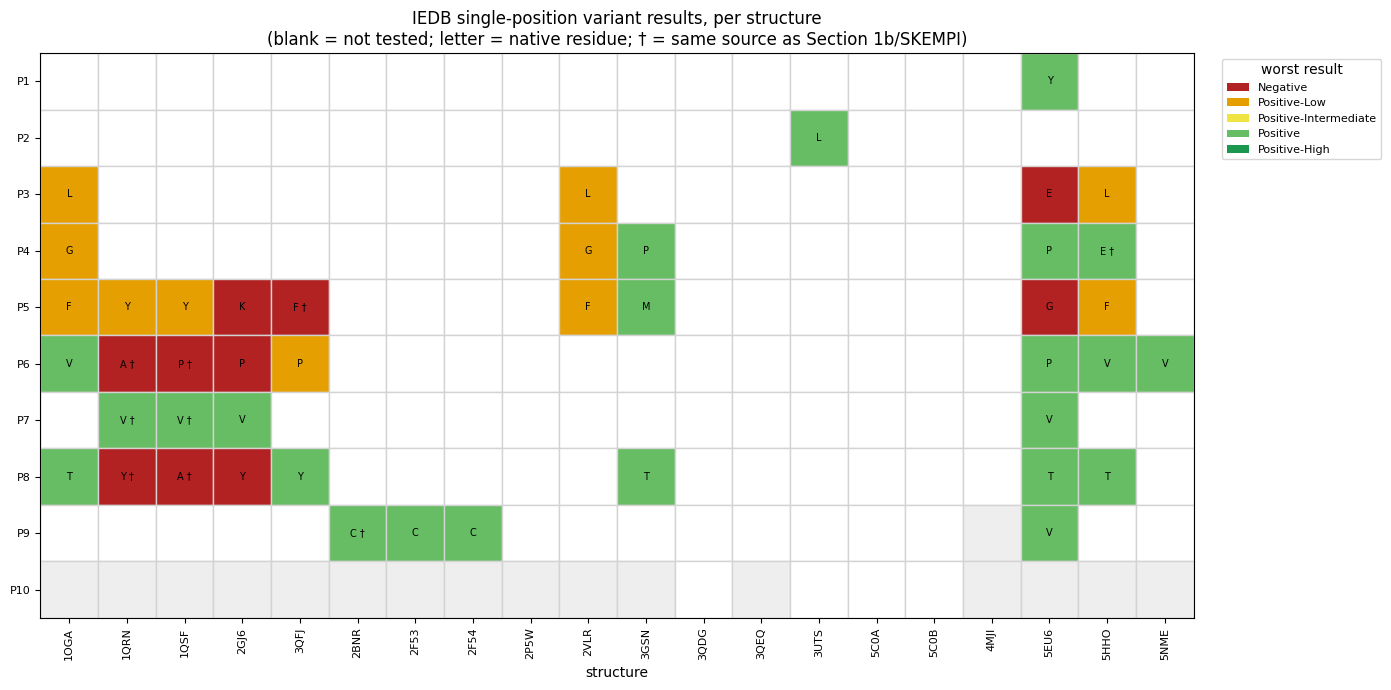

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_iedb_position_matrix.png


In [15]:
SEVERITY_COLOR = {0: "#B22222", 1: "#E69F00", 2: "#F0E442", 3: "#66BD63", 4: "#1A9850"}
pdb_order = sorted(GROUP_MAP.keys(), key=lambda p: (GROUP_MAP[p], p))
max_len = max(len(master_full.loc[p, "peptide"]) for p in pdb_order)

fig, ax = plt.subplots(figsize=(0.6 * len(pdb_order) + 2, 0.55 * max_len + 1.5))
grid = position_summary.set_index(["pdb", "position"])
for j, pdb in enumerate(pdb_order):
    for pos in range(1, max_len + 1):
        if pos > len(master_full.loc[pdb, "peptide"]):
            color = "#EEEEEE"
        elif (pdb, pos) in grid.index:
            sev = grid.loc[(pdb, pos), "worst_severity"]
            color = SEVERITY_COLOR[sev]
        else:
            color = "white"
        ax.add_patch(plt.Rectangle((j, max_len - pos), 1, 1, facecolor=color, edgecolor="lightgray"))
        if (pdb, pos) in grid.index:
            aa = grid.loc[(pdb, pos), "native_aa"]
            dagger = " †" if grid.loc[(pdb, pos), "same_source_as_skempi_1b"] else ""
            ax.text(j + 0.5, max_len - pos + 0.5, aa + dagger, ha="center", va="center", fontsize=7)
ax.set_xlim(0, len(pdb_order))
ax.set_ylim(0, max_len)
ax.set_xticks(np.arange(len(pdb_order)) + 0.5)
ax.set_xticklabels(pdb_order, rotation=90, fontsize=8)
ax.set_yticks(np.arange(max_len) + 0.5)
ax.set_yticklabels([f"P{p}" for p in range(max_len, 0, -1)], fontsize=8)
ax.set_xlabel("structure")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, label=q)
          for q, c in zip(["Negative", "Positive-Low", "Positive-Intermediate", "Positive", "Positive-High"],
                          SEVERITY_COLOR.values())]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="worst result")
ax.set_title("IEDB single-position variant results, per structure\n"
            "(blank = not tested; letter = native residue; † = same source as Section 1b/SKEMPI)")
fig.tight_layout()
out = FIG_DIR / "fig_panel5_iedb_position_matrix.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Recovery at those positions: pMHC only vs. pMHC+TCR, pooled

Every position flagged `functional_change` above (Negative or Positive-Low result), cross-referenced
against our own panel designs (T=0.1). Faint points/lines: one per (structure, position), full vs.
mhconly recovery. Bold point/line: all raw designs at all of these positions pooled together (not an
average of the per-position fractions) for the mean, with the SD **across the different positions**
(not within-design binomial noise) shown as the error bar -- so the error bar reflects how much these
positions disagree with each other, not sampling noise at any single one.

In [16]:
def load_panel_designs_cond(pdb, length, cond):
    rows = []
    for weights, fname in [("vanilla", f"vanilla_{pdb}.fa"), ("noMHC", f"nomhc_{pdb}.fa")]:
        path = ROOT / f"outputs/panel/{pdb}/{cond}/mpnn/seqs/{fname}"
        with open(path) as f:
            lines = f.read().splitlines()
        for i in range(2, len(lines) - 1, 2):
            if lines[i].startswith(">"):
                seq = lines[i + 1].strip()
                if len(seq) == length:
                    rows.append(seq)
    path = ROOT / f"outputs/panel/{pdb}/{cond}/esmif/seqs/{pdb}.fa"
    with open(path) as f:
        lines = f.read().splitlines()
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = lines[i + 1].strip()
            if len(seq) == length:
                rows.append(seq)
    path = ROOT / f"outputs/panel/{pdb}/{cond}/ligandmpnn/seqs/{pdb}.fa"
    with open(path) as f:
        lines = f.read().splitlines()
    for i in range(2, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            seq = peptide_from_ligandmpnn_line(lines[i + 1])
            if len(seq) == length:
                rows.append(seq)
    return rows

critical = position_summary[position_summary.functional_change].copy()
pooled_full_hits, pooled_mhconly_hits = [], []
per_position_recovery = []
for _, row in critical.iterrows():
    pdb, pos, native_aa = row["pdb"], row["position"], row["native_aa"]
    length = len(master_full.loc[pdb, "peptide"])
    full_peps = load_panel_designs_cond(pdb, length, "full")
    mhconly_peps = load_panel_designs_cond(pdb, length, "mhconly")
    full_hits = [p[pos - 1] == native_aa for p in full_peps]
    mhconly_hits = [p[pos - 1] == native_aa for p in mhconly_peps]
    pooled_full_hits.extend(full_hits)
    pooled_mhconly_hits.extend(mhconly_hits)
    per_position_recovery.append({"pdb": pdb, "position": pos, "native_aa": native_aa,
                                  "recovery_full": np.mean(full_hits), "recovery_mhconly": np.mean(mhconly_hits),
                                  "same_source_as_skempi_1b": row["same_source_as_skempi_1b"],
                                  "n_full": len(full_hits), "n_mhconly": len(mhconly_hits)})

per_position_df = pd.DataFrame(per_position_recovery)
# real, self-explanatory label: structure, position, native residue, and an explicit dagger on any
# entry that's the same published measurement already shown in Section 1b (SKEMPI) -- not a second,
# independent source, so it must not be visually indistinguishable from the ones that are.
per_position_df["label"] = (per_position_df["pdb"] + " P" + per_position_df["position"].astype(str)
                            + " (" + per_position_df["native_aa"] + ")"
                            + per_position_df["same_source_as_skempi_1b"].map({True: " †", False: ""}))
print(per_position_df.drop(columns=["n_full", "n_mhconly"]).to_string(index=False))
print(f"\n† = same source publication already presented in Section 1b (SKEMPI) -- "
     f"not an independent confirmation, shown here for completeness")

is_dup = per_position_df["same_source_as_skempi_1b"]
def pooled_stats(mask):
    full_hits, mhconly_hits = [], []
    for _, row in per_position_df[mask].iterrows():
        pdb, pos, native_aa = row["pdb"], row["position"], row["native_aa"]
        length = len(master_full.loc[pdb, "peptide"])
        full_hits.extend([p[pos - 1] == native_aa for p in load_panel_designs_cond(pdb, length, "full")])
        mhconly_hits.extend([p[pos - 1] == native_aa for p in load_panel_designs_cond(pdb, length, "mhconly")])
    return np.mean(full_hits), np.mean(mhconly_hits)

pooled_mean_full = np.mean(pooled_full_hits)
pooled_mean_mhconly = np.mean(pooled_mhconly_hits)
sd_across_positions_full = per_position_df["recovery_full"].std()
sd_across_positions_mhconly = per_position_df["recovery_mhconly"].std()
print(f"\npooled, ALL {len(critical)} functional-change positions (includes {is_dup.sum()} SKEMPI-duplicate): "
     f"full={pooled_mean_full:.3f} (SD across positions={sd_across_positions_full:.3f}), "
     f"mhconly={pooled_mean_mhconly:.3f} (SD across positions={sd_across_positions_mhconly:.3f})")

clean_full, clean_mhconly = pooled_stats(~is_dup)
clean_sd_full = per_position_df.loc[~is_dup, "recovery_full"].std()
clean_sd_mhconly = per_position_df.loc[~is_dup, "recovery_mhconly"].std()
print(f"pooled, EXCLUDING the {is_dup.sum()} SKEMPI-duplicate positions "
     f"({(~is_dup).sum()} genuinely IEDB-only positions): "
     f"full={clean_full:.3f} (SD across positions={clean_sd_full:.3f}), "
     f"mhconly={clean_mhconly:.3f} (SD across positions={clean_sd_mhconly:.3f})")

 pdb  position native_aa  recovery_full  recovery_mhconly  same_source_as_skempi_1b         label
1OGA         3         L       0.759371          0.584291                     False   1OGA P3 (L)
1OGA         4         G       1.000000          0.000125                     False   1OGA P4 (G)
1OGA         5         F       0.519842          0.536885                     False   1OGA P5 (F)
1QRN         5         Y       0.311950          0.000000                     False   1QRN P5 (Y)
1QRN         6         A       0.000000          0.000050                      True 1QRN P6 (A) †
1QRN         8         Y       0.017368          0.000000                      True 1QRN P8 (Y) †
1QSF         5         Y       0.707667          0.142318                     False   1QSF P5 (Y)
1QSF         6         P       1.000000          1.000000                      True 1QSF P6 (P) †
1QSF         8         A       0.012170          0.004098                      True 1QSF P8 (A) †
2GJ6         5      

pooled, EXCLUDING the 5 SKEMPI-duplicate positions (16 genuinely IEDB-only positions): full=0.584 (SD across positions=0.366), mhconly=0.384 (SD across positions=0.415)


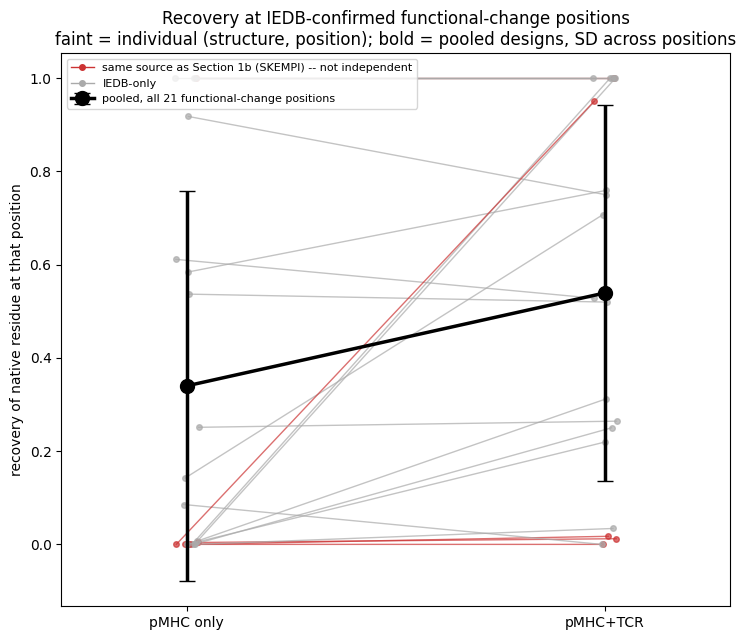

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_iedb_critical_position_recovery_shift.png


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
rng = np.random.RandomState(0)
xs = {"mhconly": 0.0, "full": 1.0}
for _, row in per_position_df.iterrows():
    jitter = rng.uniform(-0.03, 0.03)
    color = "#CC3333" if row["same_source_as_skempi_1b"] else "#AAAAAA"
    ax.plot([xs["mhconly"] + jitter, xs["full"] + jitter],
           [row["recovery_mhconly"], row["recovery_full"]], color=color, alpha=0.7, linewidth=1,
           zorder=2, marker="o", markersize=4)

ax.errorbar([xs["mhconly"], xs["full"]], [pooled_mean_mhconly, pooled_mean_full],
           yerr=[sd_across_positions_mhconly, sd_across_positions_full], color="black", linewidth=2.5,
           marker="o", markersize=10, capsize=6, zorder=5,
           label=f"pooled, all {len(critical)} functional-change positions")
ax.plot([], [], color="#CC3333", marker="o", markersize=4, linewidth=1,
       label="same source as Section 1b (SKEMPI) -- not independent")
ax.plot([], [], color="#AAAAAA", marker="o", markersize=4, linewidth=1, label="IEDB-only")

ax.set_xticks([0, 1])
ax.set_xticklabels(["pMHC only", "pMHC+TCR"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("recovery of native residue at that position")
ax.set_title("Recovery at IEDB-confirmed functional-change positions\n"
             "faint = individual (structure, position); bold = pooled designs, SD across positions")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
out = FIG_DIR / "fig_panel5_iedb_critical_position_recovery_shift.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### 3-row summary matrix: IEDB result, pMHC-only recovery, pMHC+TCR recovery

One column per (structure, position) functional-change entry, plus a MEAN column. Top row is IEDB's
categorical severity (Negative=0 through Positive-High=4) -- not a literal $\Delta$KD in nM, since the
API doesn't expose numeric KD values for most of these entries, only the qualitative bin. Middle and
bottom rows are our own recovery, pMHC only vs. pMHC+TCR, same as the point plot above but laid out
position-by-position instead of as a distribution.

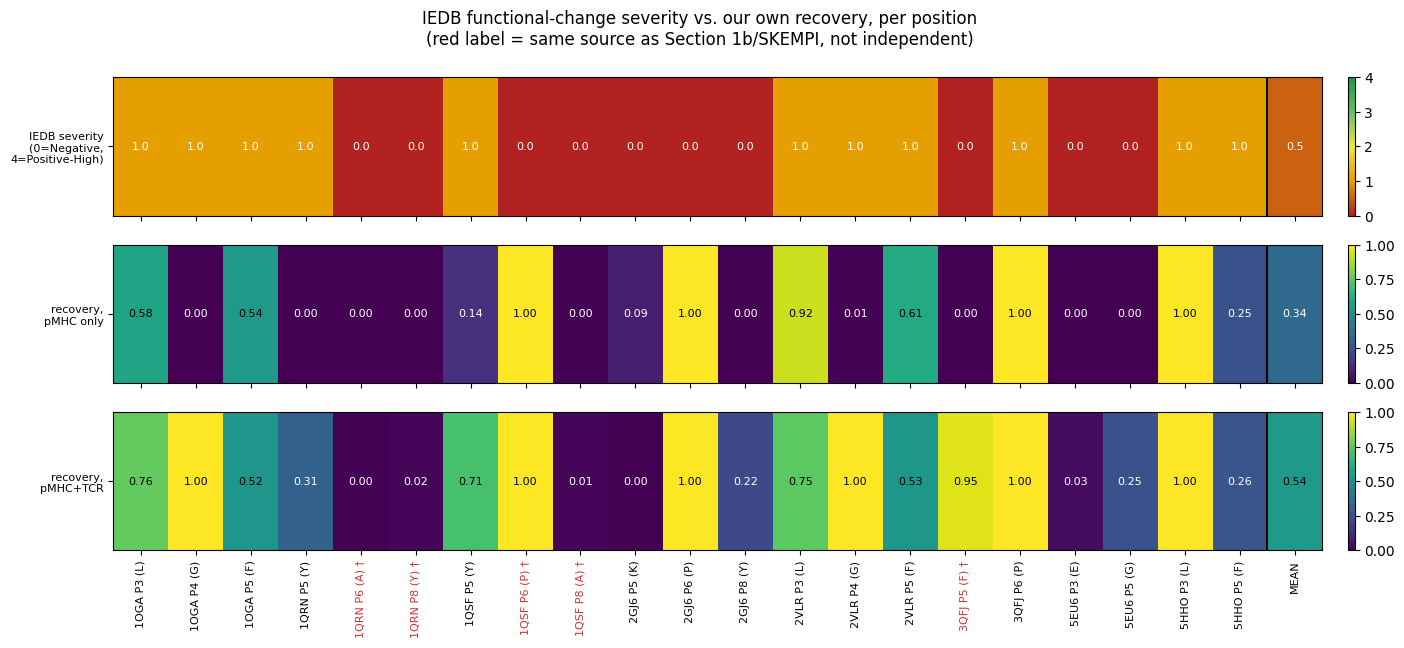

wrote /home/ubuntu/if-mhc/figures/fig_panel5_skempi_validation/fig_panel5_iedb_severity_recovery_matrix.png


In [18]:
from matplotlib.colors import LinearSegmentedColormap

matrix_df = per_position_df.merge(critical[["pdb", "position", "worst_severity"]], on=["pdb", "position"])
matrix_df = matrix_df.sort_values(["pdb", "position"]).reset_index(drop=True)

labels = matrix_df["label"].tolist() + ["MEAN"]
row_severity = matrix_df["worst_severity"].tolist() + [matrix_df["worst_severity"].mean()]
row_mhconly = matrix_df["recovery_mhconly"].tolist() + [matrix_df["recovery_mhconly"].mean()]
row_full = matrix_df["recovery_full"].tolist() + [matrix_df["recovery_full"].mean()]
n = len(labels)

severity_cmap = LinearSegmentedColormap.from_list(
    "severity", [SEVERITY_COLOR[i] for i in range(5)])

fig, axes = plt.subplots(3, 1, figsize=(0.55 * n + 2, 6.5), sharex=True)
row_specs = [
    (row_severity, severity_cmap, 0, 4, "IEDB severity\n(0=Negative,\n4=Positive-High)", "{:.1f}"),
    (row_mhconly, "viridis", 0, 1, "recovery,\npMHC only", "{:.2f}"),
    (row_full, "viridis", 0, 1, "recovery,\npMHC+TCR", "{:.2f}"),
]
for ax, (values, cmap, vmin, vmax, ylabel, fmt) in zip(axes, row_specs):
    arr = np.array(values).reshape(1, -1)
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    for j, v in enumerate(values):
        norm = (v - vmin) / (vmax - vmin)
        color = "white" if norm < 0.5 else "black"
        ax.text(j, 0, fmt.format(v), ha="center", va="center", color=color, fontsize=8)
    ax.axvline(n - 1.5, color="black", linewidth=1.5)
    ax.set_yticks([0])
    ax.set_yticklabels([ylabel], fontsize=8)
    ax.set_xticks([])
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

axes[-1].set_xticks(range(n))
axes[-1].set_xticklabels(labels, rotation=90, fontsize=8)
for tick, is_dup in zip(axes[-1].get_xticklabels(), matrix_df["same_source_as_skempi_1b"].tolist() + [False]):
    if is_dup:
        tick.set_color("#CC3333")
fig.suptitle("IEDB functional-change severity vs. our own recovery, per position\n"
            "(red label = same source as Section 1b/SKEMPI, not independent)", y=0.99)
fig.tight_layout()
out = FIG_DIR / "fig_panel5_iedb_severity_recovery_matrix.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## Synthesis

**Scope, stated plainly:** the panel's own SKEMPI overlap (Section 1b) is real but thin -- 4 structures,
1 peptide mutation each. It already shows a genuine anchor-tolerance lead (2BNR: native Cys at
$P\Omega$ measured *weaker* than a Val substitution) and a clean split in our own recovery at those 4
single positions (0.95 down to 0.0), but $n=4$ points can't support a position-category analysis the way
3HG1's 5-position scan can. Everything from Section 2 onward is 3HG1 -- richer, but outside the panel.

The SKEMPI alanine scan didn't touch the two positions we already suspected were special for a
*different* reason (P2 and P10, the canonical MHC pockets B/F anchors) -- those were presumably excluded
from a TCR-affinity assay specifically because mutating them risks killing peptide loading/presentation
itself, confounding a "TCR contact" readout. What it *did* test (P4, P6, P7, P8, P9) are the
TCR-facing, solvent-exposed epitope positions, and alanine there measurably abolishes MEL5 binding at
every one of them -- a real, independent confirmation that this specific set of 5 positions matters for
TCR recognition, not just a contact-count proxy.

Whether our own recovery/entropy actually distinguishes that confirmed-critical set from everything else
is the real question this notebook answers with actual numbers (see Section 5's printed output) rather
than assuming it from the panel's contact-based analysis alone. Either way, the honest caveat from
Section 2 stands: every SKEMPI outcome here is categorical (n.b. = binding abolished), not a graded
$\Delta\Delta G$ -- so this validates *identity* of important positions, not a dose-response, and $n=5$
per group is a small, exploratory comparison, not a confirmatory one.

**Section 6's group-level test (SKEMPI-critical vs. everything else) didn't reach significance** (recovery
delta p=0.40, agreement delta p=0.18, $n=5$ vs $n=5$) -- but the group average hides a floor effect: P8
and P9 are already near-zero recovery in the *full* context, so removing the TCR can't drop them much
further, which drags the group mean down. Look at the individual positions instead (Section 6's plot):
**P4 collapses from ~98% recovery (pMHC+TCR) to ~0% (pMHC only)** -- as clean a TCR-dependence signature
as this project has produced anywhere. **P5 shows the identical collapse (~68% to 0%)**, despite SKEMPI
never testing P5 at all -- this notebook's own data is proposing P5 as a TCR-recognition position that
the published alanine scan simply didn't happen to cover, a concrete, testable hypothesis rather than a
speculation. By contrast, the two MHC anchors (P2, P10) barely move between contexts (P2 even ticks
slightly *up* without the TCR) -- exactly the contrast this analysis was designed to detect: TCR-driven
positions lose their identity when the TCR is removed, pMHC-anchor positions don't, because they were
never the TCR's business in the first place.